# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math



#### **1.1.1**
Load the dataset

In [4]:
# Load the data
df=pd.read_csv("D:\GitHub\car-price-app\data\Car_Price_data.csv")
df.head()



,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [5]:
## Check data shape
df.shape

(15915, 23)

 Dataset contains 15k+ records (15915 rows, 23 columns) with features like mileage, fuel type, engine power, etc.

In [6]:
## check data infos
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,15915.0,18024.380584,7381.679318,4950.0,12850.0,16900.0,21900.0,74600.0
km,15915.0,32089.995708,36977.214964,0.0,1920.5,20413.0,46900.0,317000.0
Gears,15915.0,5.937355,0.704772,5.0,5.0,6.0,6.0,8.0
age,15915.0,1.389695,1.121306,0.0,0.0,1.0,2.0,3.0
Previous_Owners,15915.0,1.042853,0.339178,0.0,1.0,1.0,1.0,4.0
hp_kW,15915.0,88.499340,26.674341,40.0,66.0,85.0,103.0,294.0
Inspection_new,15915.0,0.247063,0.431317,0.0,0.0,0.0,0.0,1.0
Displacement_cc,15915.0,1428.661891,275.804272,890.0,1229.0,1461.0,1598.0,2967.0
Weight_kg,15915.0,1337.700534,199.682385,840.0,1165.0,1295.0,1472.0,2471.0
cons_comb,15915.0,4.832124,0.867530,3.0,4.1,4.8,5.4,9.1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [5]:
# Find the proportion of missing values in each column and handle if found

## 1. check if string value in object columns are 'none','null','nan',''

for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].astype(str).str.lower().unique()
    if any(x in unique_vals for x in ['none','null','nan','']):
        print(col, unique_vals[:10])

## 2. check if there are any Empty string
for col in df.columns:
    empty_count = (df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(col, empty_count)

# 3. replace all  ['None', 'none', 'NULL', 'null', 'NaN', 'nan', ''] to NA before counting missing 

df.replace(['None', 'none', 'NULL', 'null', 'NaN', 'nan', ''], pd.NA, inplace=True)


# 4. Check missing values (count + proportion)
# Missing count + %
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_pct
}).sort_values(by='Missing_%', ascending=False)

missing_df


,Missing_Count,Missing_%
make_model,0,0.0
age,0,0.0
Drive_chain,0,0.0
Weight_kg,0,0.0
Displacement_cc,0,0.0
Gearing_Type,0,0.0
Upholstery_type,0,0.0
Paint_Type,0,0.0
Inspection_new,0,0.0
hp_kW,0,0.0


No missing values were detected in the dataset, as all columns contain complete observations. 
This indicates that the dataset is well-prepared and does not require imputation. 
Therefore, all records were retained for further analysis.

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

Numerical features: ['km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']


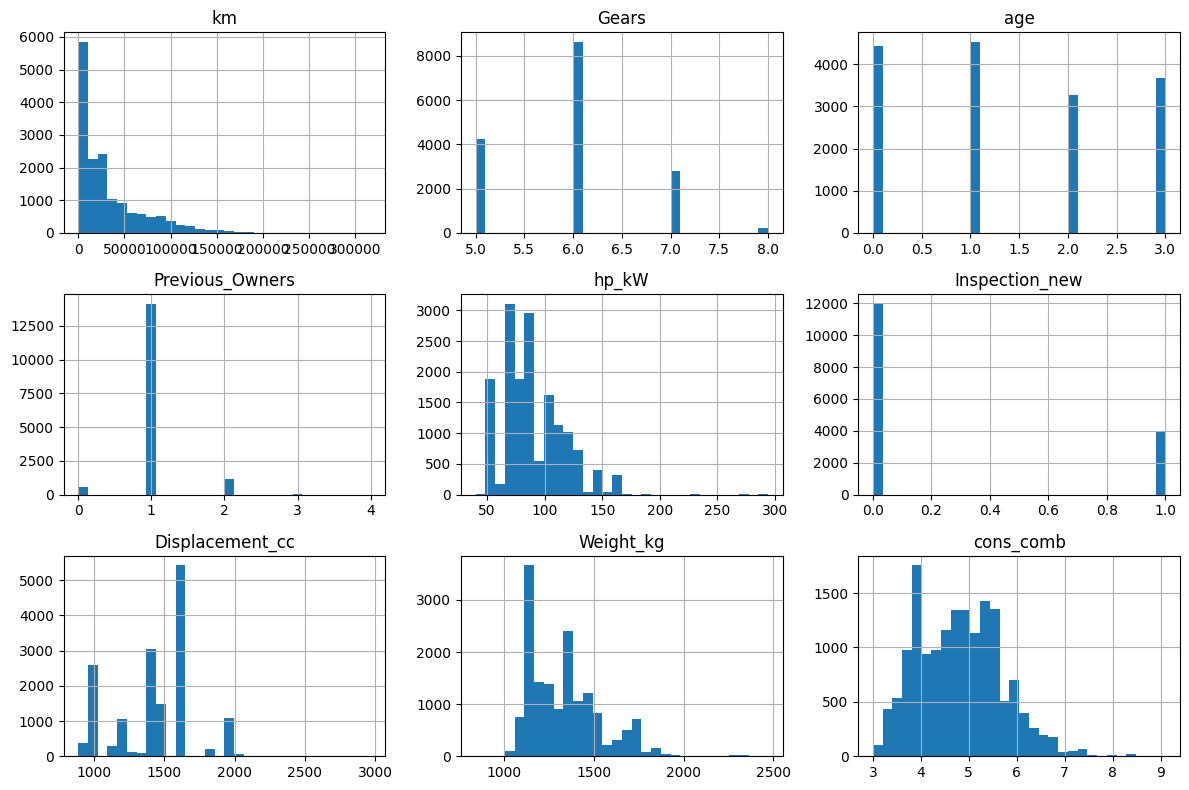

In [6]:
# Identify numerical features and plot histograms


## identify numberical features

num_cols=df.select_dtypes(include=["int64","float64"]).columns.to_list()

# remove target Price column

num_cols.remove("price")

print("Numerical features:", num_cols)


# Plot histogram

df[num_cols].hist(figsize=(12,8),bins=30)
plt.tight_layout()
plt.show()


Numerical features such as mileage (km), age, engine power (hp_kw), and weight show varied distributions. 
Several features are right-skewed, indicating the presence of extreme values or outliers. 
The target variable (price) is also typically right-skewed, suggesting the need for log transformation to stabilize variance

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

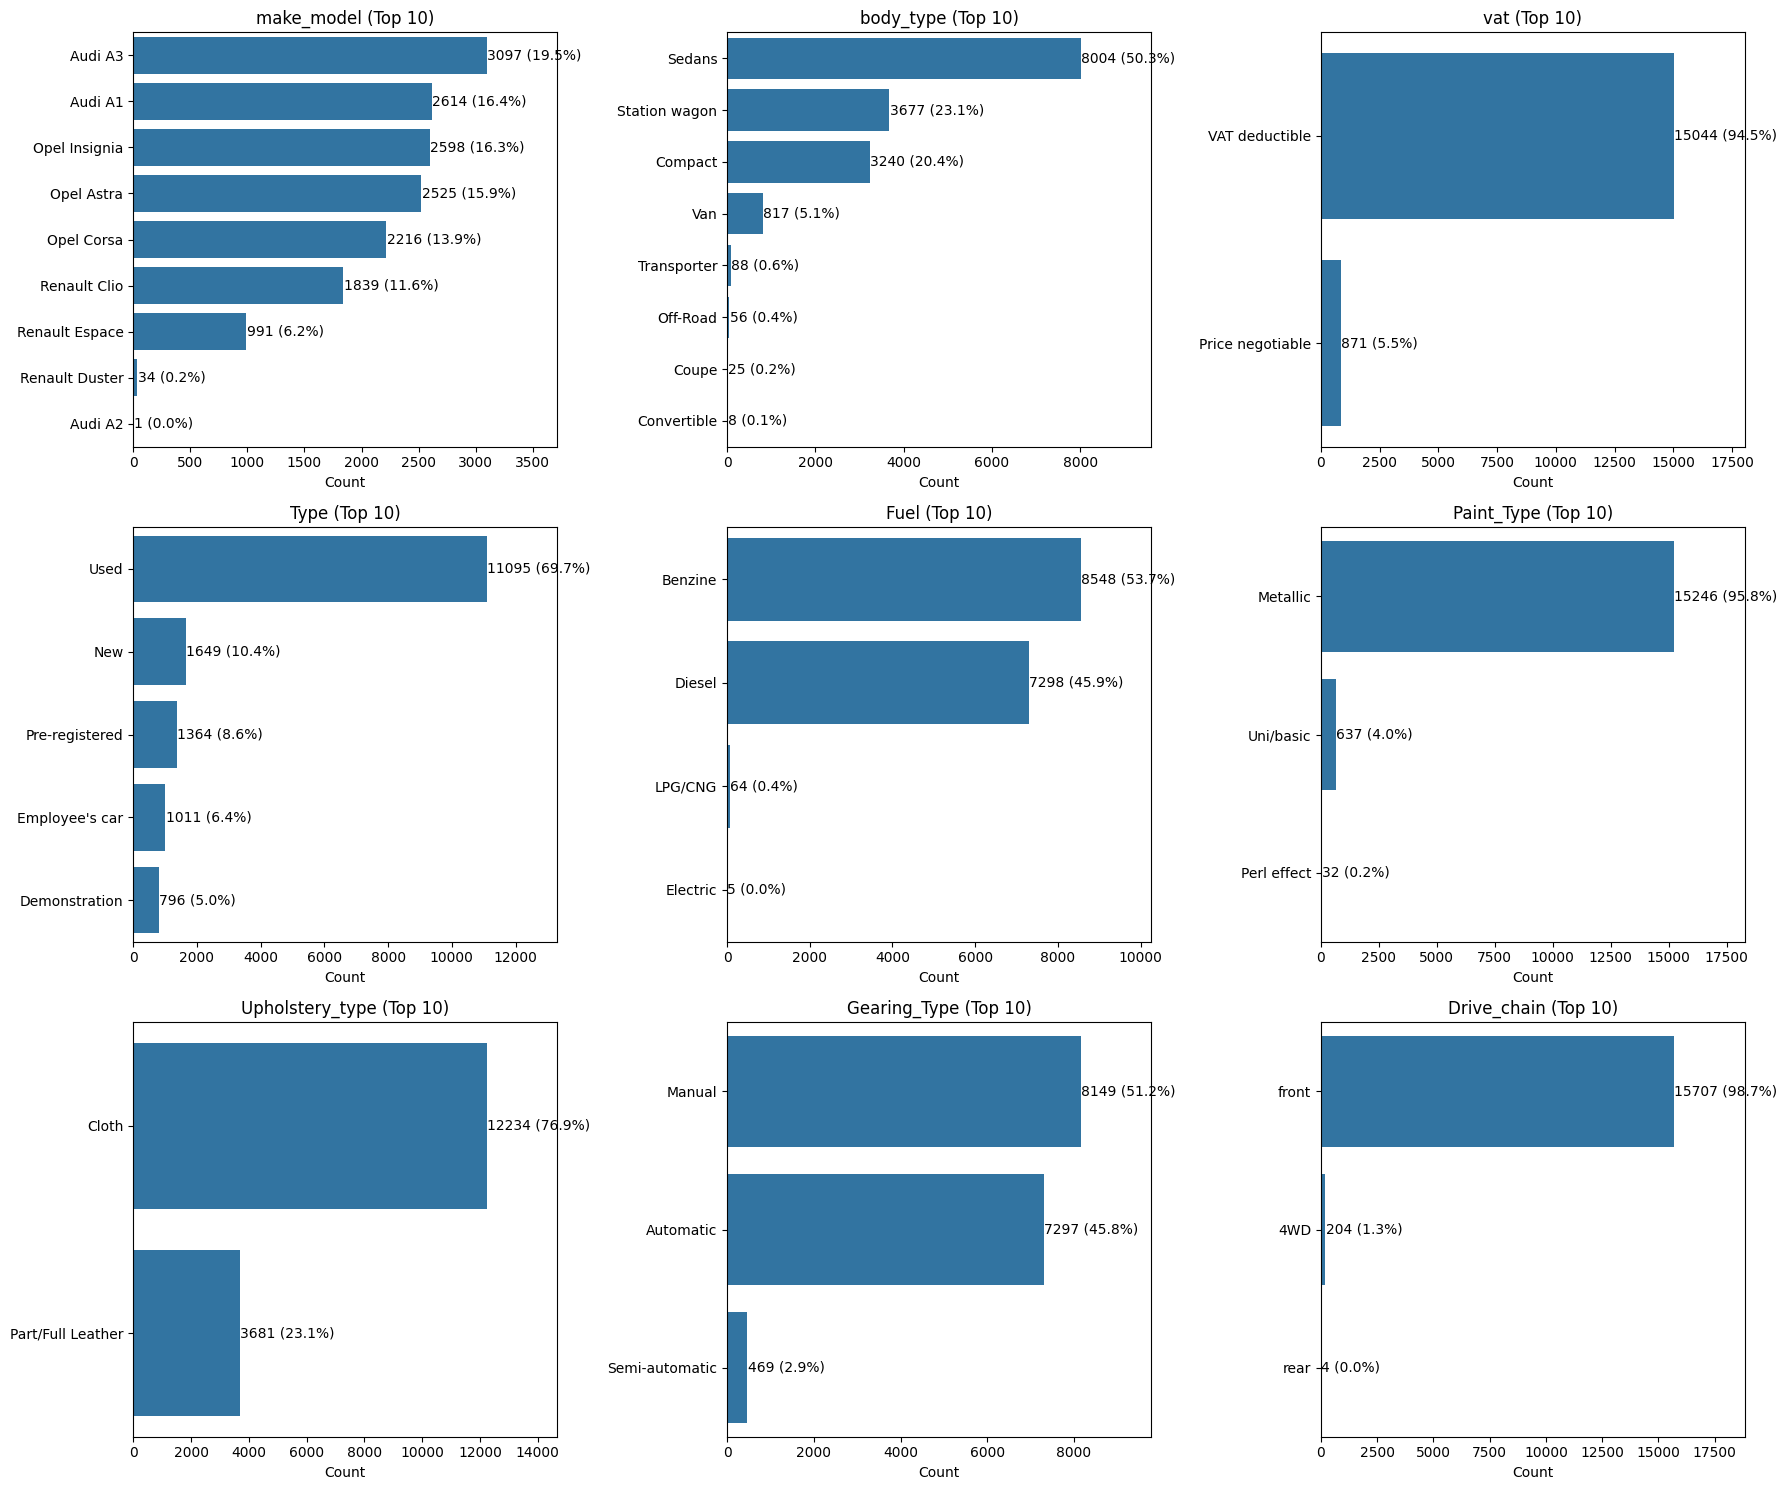

In [7]:
# Identify categorical columns and check their frequency distributions

## identiy categorical columns



# 1. categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# 2. Exclude 4 specific columns in plot
exclude_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

cat_cols = [c for c in cat_cols if c not in exclude_cols]

# 3. setup grid
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 4. plot + annotate
for i, col in enumerate(cat_cols):
    
    top_values = df[col].value_counts().nlargest(10)
    total = top_values.sum()
    
    ax = sns.countplot(
        y=df[col],
        order=top_values.index,
        ax=axes[i]
    )
    
    # annotate value + %
    for p in ax.patches:
        count = int(p.get_width())
        pct = 100 * count / total
        
        ax.annotate(
            f'{count} ({pct:.1f}%)',
            (p.get_width() + 5, p.get_y() + p.get_height()/2),
            va='center'
        )
        ax.set_xlim(0, max(top_values) * 1.2)
    
    axes[i].set_title(f"{col} (Top 10)")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
 

# 5. remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

The columns Comfort_Convenience, Entertainment_Media, Extras, and Safety_Security contain multiple values within each observation and therefore cannot be treated as standard categorical variables: 
 + These features represent lists of attributes rather than single categories. 
 + Dropping them would result in the loss of important information. 
 + Instead, they were transformed into numerical features by counting the number of available options, which provides a meaningful representation of feature richness while avoiding high-dimensional encoding


#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\4080754391.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\4080754391.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(


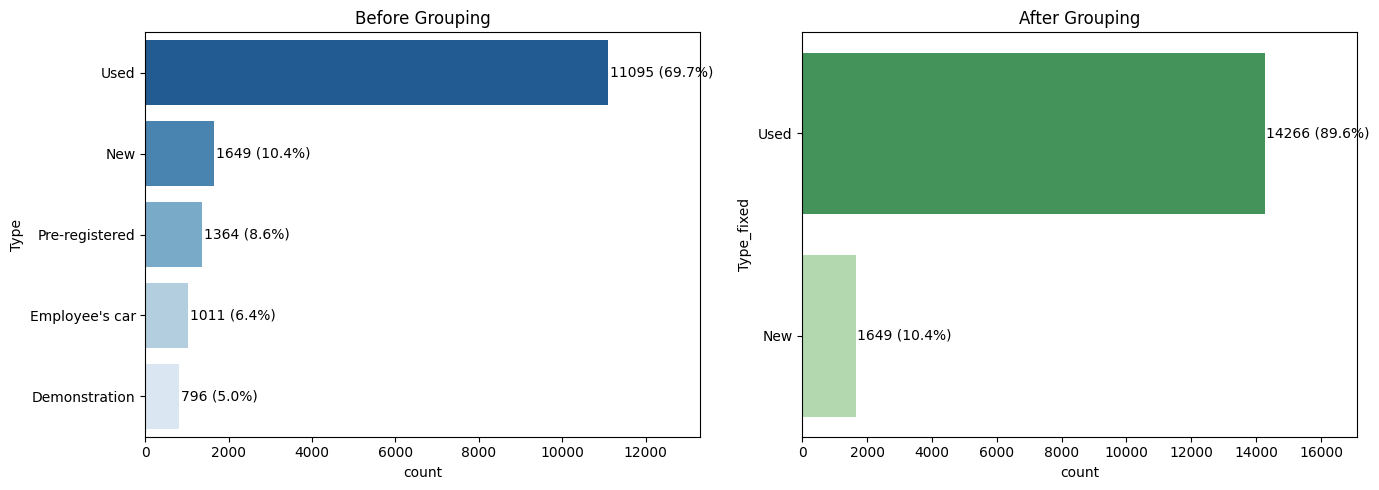

In [8]:
# Fix columns as needed

## Caculate count value & percentage of value under Type column
type_counts=df['Type'].value_counts()
type_pct=df['Type'].value_counts(normalize=True)*100

#Combine
type_summary=pd.DataFrame({"Count":type_counts,"Percentage (%)": type_pct.round(2)})
type_summary.sort_values(by="Percentage (%)", ascending=False)

## 	Fix columns with low frequency values and class imbalances

###
#The 'Used' category clearly dominates the dataset, accounting for the majority of observations. 
#Other categories such as 'New', 'Pre-registered', and 'Demonstration' have significantly lower representation, 
#indicating strong class imbalance. This imbalance suggests the need for grouping similar categories to improve model stability.
#***

df['Type_fixed'] = df['Type'].replace({
    'Pre-registered': 'Used',
    "Employee's car": 'Used',
    'Demonstration': 'Used'
})

# Plot Before & After 


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -------- BEFORE --------
counts_before = df['Type'].value_counts()
total = len(df)

ax1 = sns.countplot(
    y='Type',
    data=df,
    order=counts_before.index,
    palette='Blues_r',
    ax=axes[0]
)

for p in ax1.patches:
    count = int(p.get_width())
    pct = 100 * count / total
    ax1.annotate(
        f'{count} ({pct:.1f}%)',
        (count + 50, p.get_y() + p.get_height()/2),
        va='center'
    )

ax1.set_title("Before Grouping")
ax1.set_xlim(0, counts_before.max() * 1.2)


# -------- AFTER --------
counts_after = df['Type_fixed'].value_counts()

ax2 = sns.countplot(
    y='Type_fixed',
    data=df,
    order=counts_after.index,
    palette='Greens_r',
    ax=axes[1]
)

for p in ax2.patches:
    count = int(p.get_width())
    pct = 100 * count / total
    ax2.annotate(
        f'{count} ({pct:.1f}%)',
        (count + 50, p.get_y() + p.get_height()/2),
        va='center'
    )

ax2.set_title("After Grouping")
ax2.set_xlim(0, counts_after.max() * 1.2)

plt.tight_layout()
plt.show()



The 'Used' category clearly dominates the dataset, accounting for the majority of observations. Other categories such as 'New', 'Pre-registered', and 'Demonstration' have significantly lower representation, indicating strong class imbalance.  This imbalance suggests the need for grouping similar categories to improve model stability.

Before grouping, the 'Type' variable shows significant class imbalance, with 'Used' dominating the dataset and several categories having very low frequency. 

After grouping similar categories into 'Used', the distribution becomes more balanced and simplified. 
This reduces noise and helps the model learn more effectively by focusing on meaningful distinctions


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

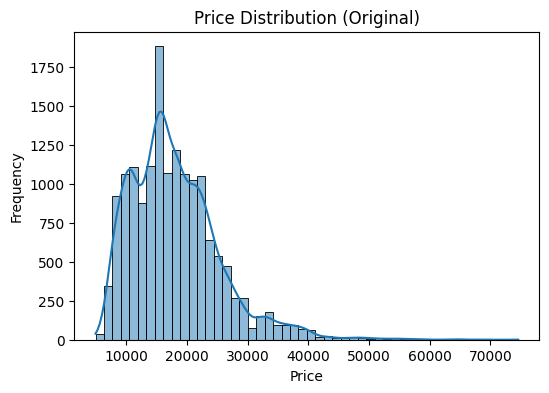

In [9]:
# Plot histograms for target feature

plt.figure(figsize=(6,4))

sns.histplot(df['price'], bins=50, kde=True)

plt.title("Price Distribution (Original)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

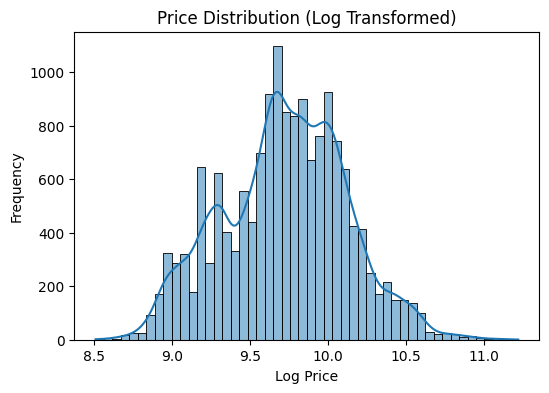

In [10]:
# Transform the target feature

import numpy as np

 # using log1p to apply transformation log1p(x)=log(1+x)
df['price_log'] = np.log1p(df['price'])

plt.figure(figsize=(6,4))

sns.histplot(df['price_log'], bins=50, kde=True)

plt.title("Price Distribution (Log Transformed)")
plt.xlabel("Log Price")
plt.ylabel("Frequency")

plt.show()

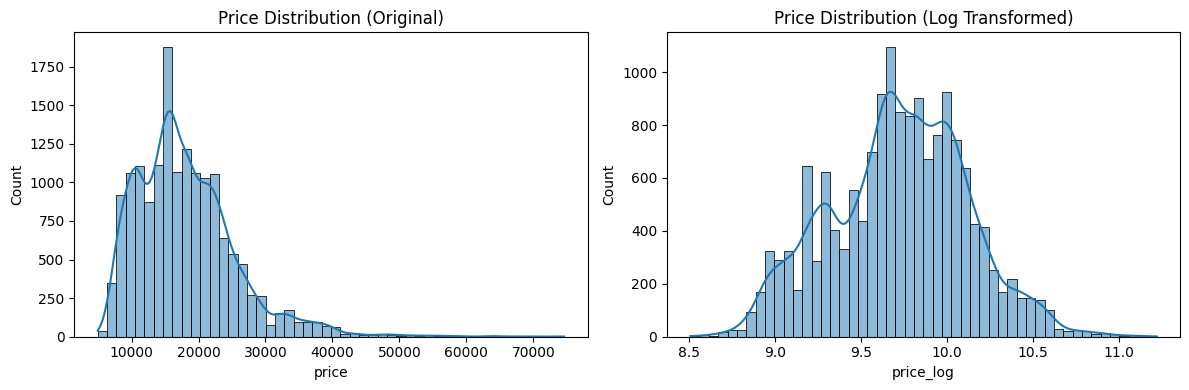

In [11]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Price Distribution (Original)")

sns.histplot(df['price_log'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Price Distribution (Log Transformed)")

plt.tight_layout()
plt.show()

The original price distribution is highly right-skewed, with a long tail of high-value observations. 
After applying a log transformation, the distribution becomes more symmetric and closer to normal. 

This transformation reduces the impact of extreme values and improves model performance by stabilizing variance.

KDE (Kernel Density Estimation) provides a smooth estimate of the data distribution, 
making it easier to identify key characteristics such as skewness, spread, and modality. 

In this case, the KDE curve shows a strong right skew in the original price distribution, 
indicating a concentration of lower-priced vehicles and a long tail of higher-priced ones. 

After transformation, the KDE becomes more symmetric, suggesting improved distributional properties for modeling.

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

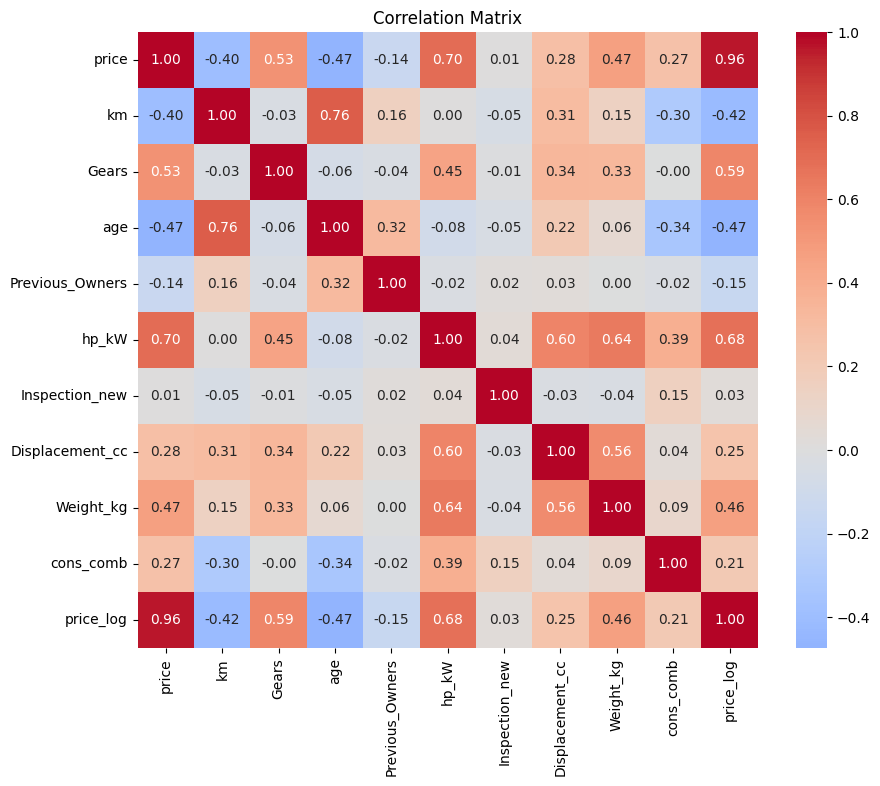

In [12]:
# Visualise correlation

#  numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# correlation matrix
corr = df[num_cols].corr()

# plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

The correlation heatmap shows the relationships between numerical variables and the target variable (Price Log). 
Features such as hp_kW, Gears, weight_kg, and displacement_cc tend to have positive correlations with price, indicating that more powerful and heavier vehicles are generally more expensive. 

On the other hand, features such as age ,km, previous_owner show negative correlations, suggesting that older cars with higher mileage tend to have lower prices.


#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

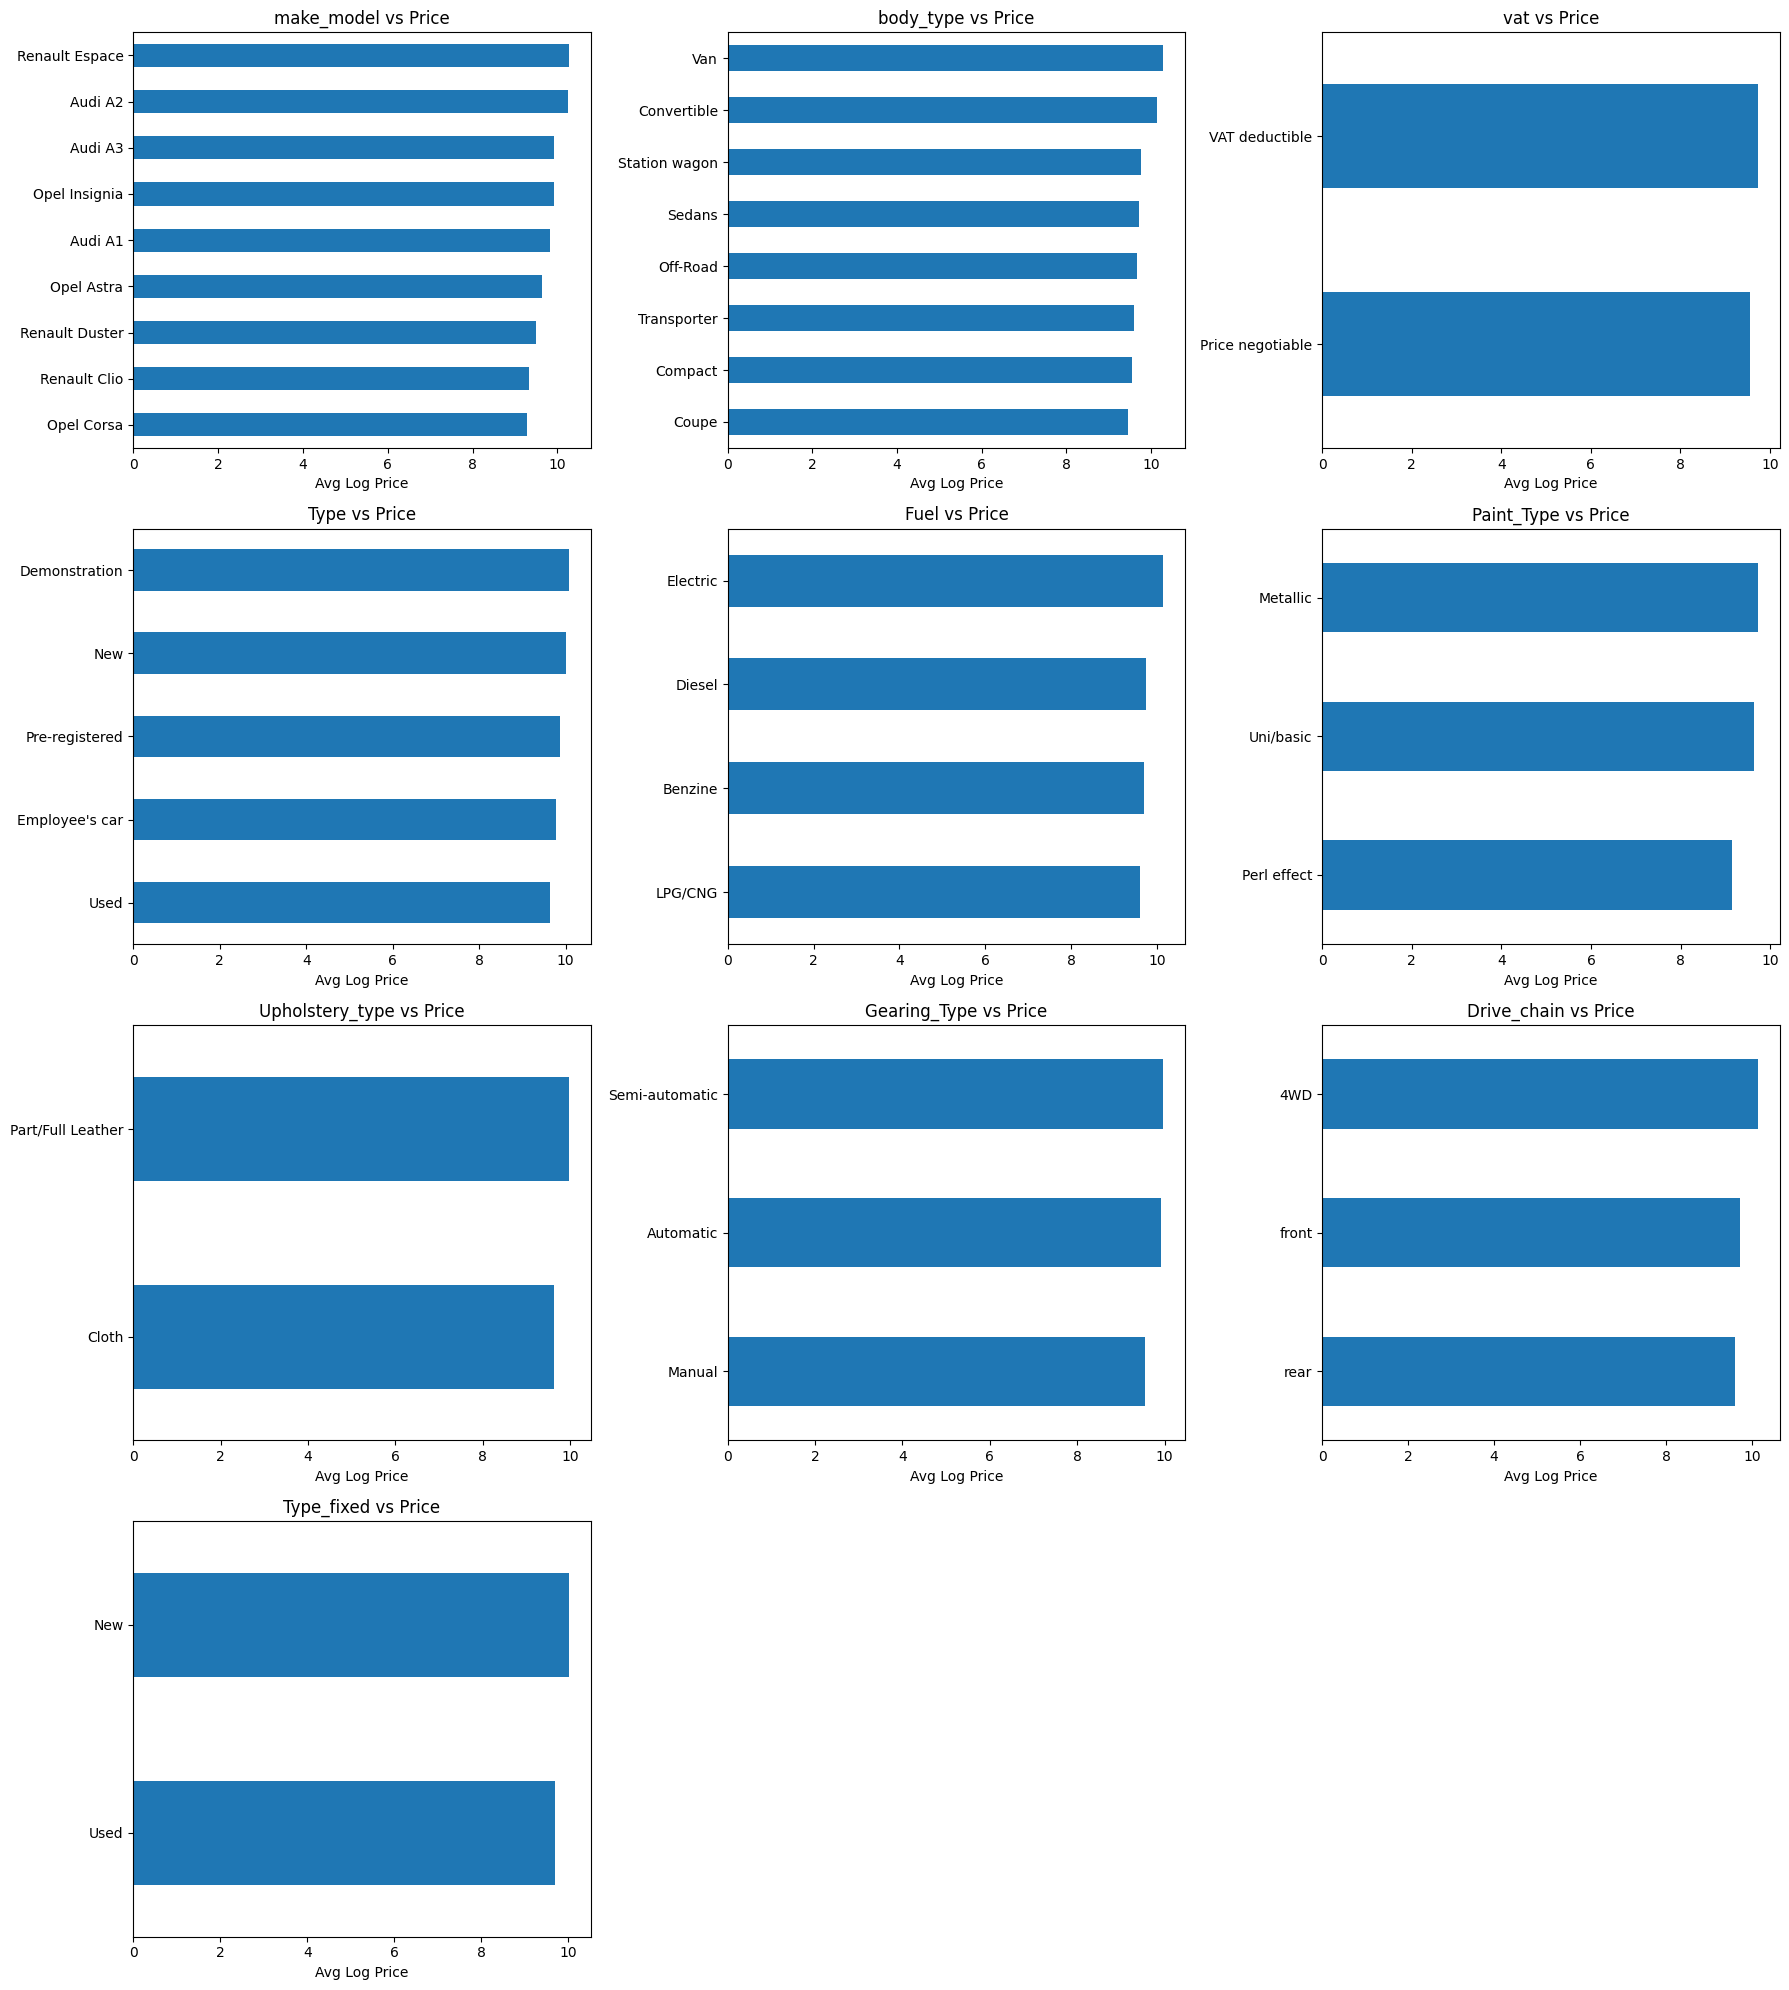

In [13]:
# Comparing average values of target for different categories



import matplotlib.pyplot as plt
import math

# 1.  categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# 2. Exclude 4 special columns
exclude_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

cat_cols = [c for c in cat_cols if c not in exclude_cols]

# 3. setup grid
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# 4. plot từng column
for i, col in enumerate(cat_cols):
    
    avg_price = (
        df.groupby(col)['price_log']
        .mean()
        .sort_values(ascending=True)
        .tail(10)   # lấy top 10
    )
    
    avg_price.plot(
        kind='barh',
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Price")
    axes[i].set_xlabel("Avg Log Price")
    axes[i].set_ylabel("")

# 5. xoá plot dư
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1.	Make Model vs Price

Certain car models have significantly higher average prices, indicating strong brand and model effects. 
Higher-end models tend to dominate the upper price range, while more common models are associated with lower prices.

2.	Body Type vs Price

Larger vehicle types such as SUVs and Sedans tend to have higher average prices,  while smaller cars such as Compact models are generally cheaper. 
This suggests that vehicle size and class are important factors influencing price.

3.	VAT vs Price

Cars with VAT deductible status tend to have higher average prices compared to price-negotiable vehicles. 
This may indicate that VAT-deductible cars are newer or sold by dealerships.

4.	Type_Fixed ( after group) vs Price

New cars have significantly higher average prices compared to used vehicles. 
This confirms that vehicle condition is one of the strongest determinants of price.

5.	Fuel vs Price

Fuel type influences price, with electric and hybrid vehicles generally having higher average prices, 
while petrol and diesel vehicles are more moderately priced.

6.	Pain_Type vs Price

Certain paint types such as metallic finishes are associated with higher prices, possibly reflecting premium options or better vehicle condition.

7.	Gear_Type vs Price

Automatic /semi auto vehicles tend to have higher average prices compared to manual ones,  reflecting consumer preference and convenience.

8.	Drive_Chain vs Price

All-wheel or four-wheel drive vehicles (4WD) generally have higher prices compared to front-wheel drive cars, 
indicating that drivetrain capability adds value.

9.	Upholstery_Type Price

Premium interior materials such as leather upholstery are associated with higher prices, 
while basic materials correspond to lower-priced vehicles.

10.	Summary:

Overall, categorical variables show strong relationships with the target variable, as different categories exhibit significant variation in average prices. 
Features related to vehicle condition, fuel type, transmission, and brand/model appear to be key drivers of price differences


### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [14]:
# Outliers present in each column

# using IQR method

num_cols=df.select_dtypes(include=["int64","Float64"]).columns
outlier_summary = {}

for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR= Q3-Q1

    lower= Q1 - 1.5*IQR
    upper= Q3 + 1.5*IQR

    outliers= df[(df[col] <  lower) | (df[col]>upper)]
    outlier_summary[col] = len(outliers)

# hiển thị
pd.Series(outlier_summary).sort_values(ascending=False)

Inspection_new     3932
Previous_Owners    1757
km                  689
price               479
hp_kW               361
Gears               225
cons_comb           125
Weight_kg            87
price_log            71
Displacement_cc      21
age                   0
dtype: int64

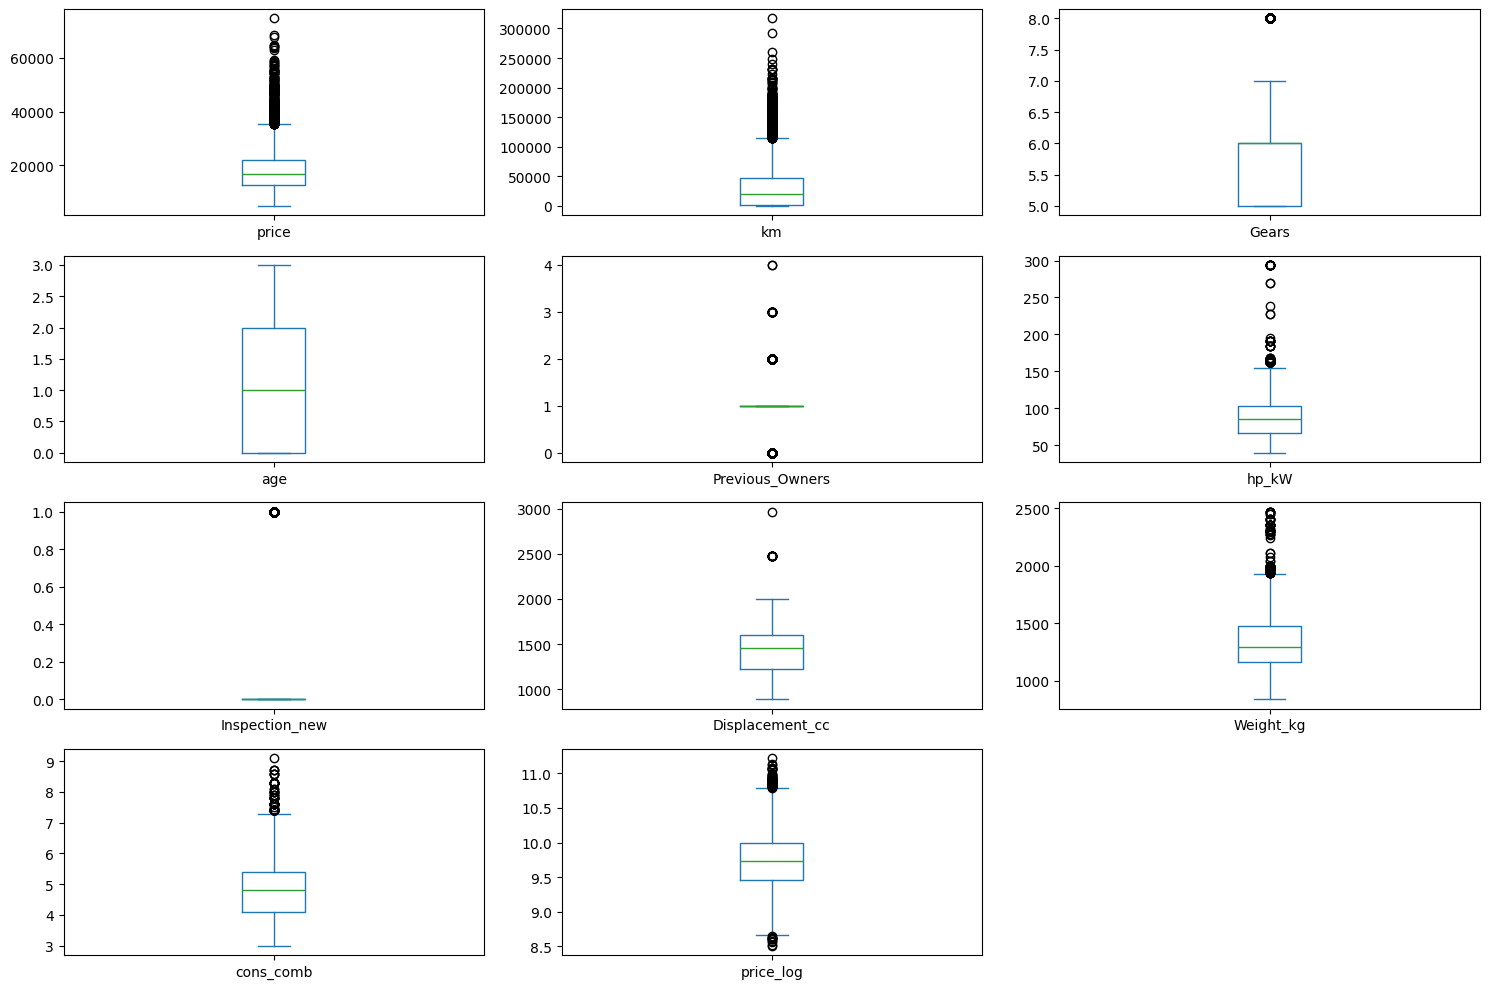

In [15]:


df[num_cols].plot(kind='box', subplots=True, layout=(4,3), figsize=(15,10))
plt.tight_layout()
plt.show()

Outliers are present in several numerical features such as price, km, and engine-related variables. 
These extreme values may represent unusually expensive vehicles or cars with exceptionally high mileage. 

Such outliers can negatively impact model performance, especially for linear models.

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [16]:
# Handle outliers

# copy firstly

df_before = df.copy()

## Apply capping (outlier handling)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df_after = df.copy()

for col in num_cols:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_after[col] = df_after[col].clip(lower, upper)








C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\1449626929.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\1449626929.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\1449626929.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_1668\1449626929.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

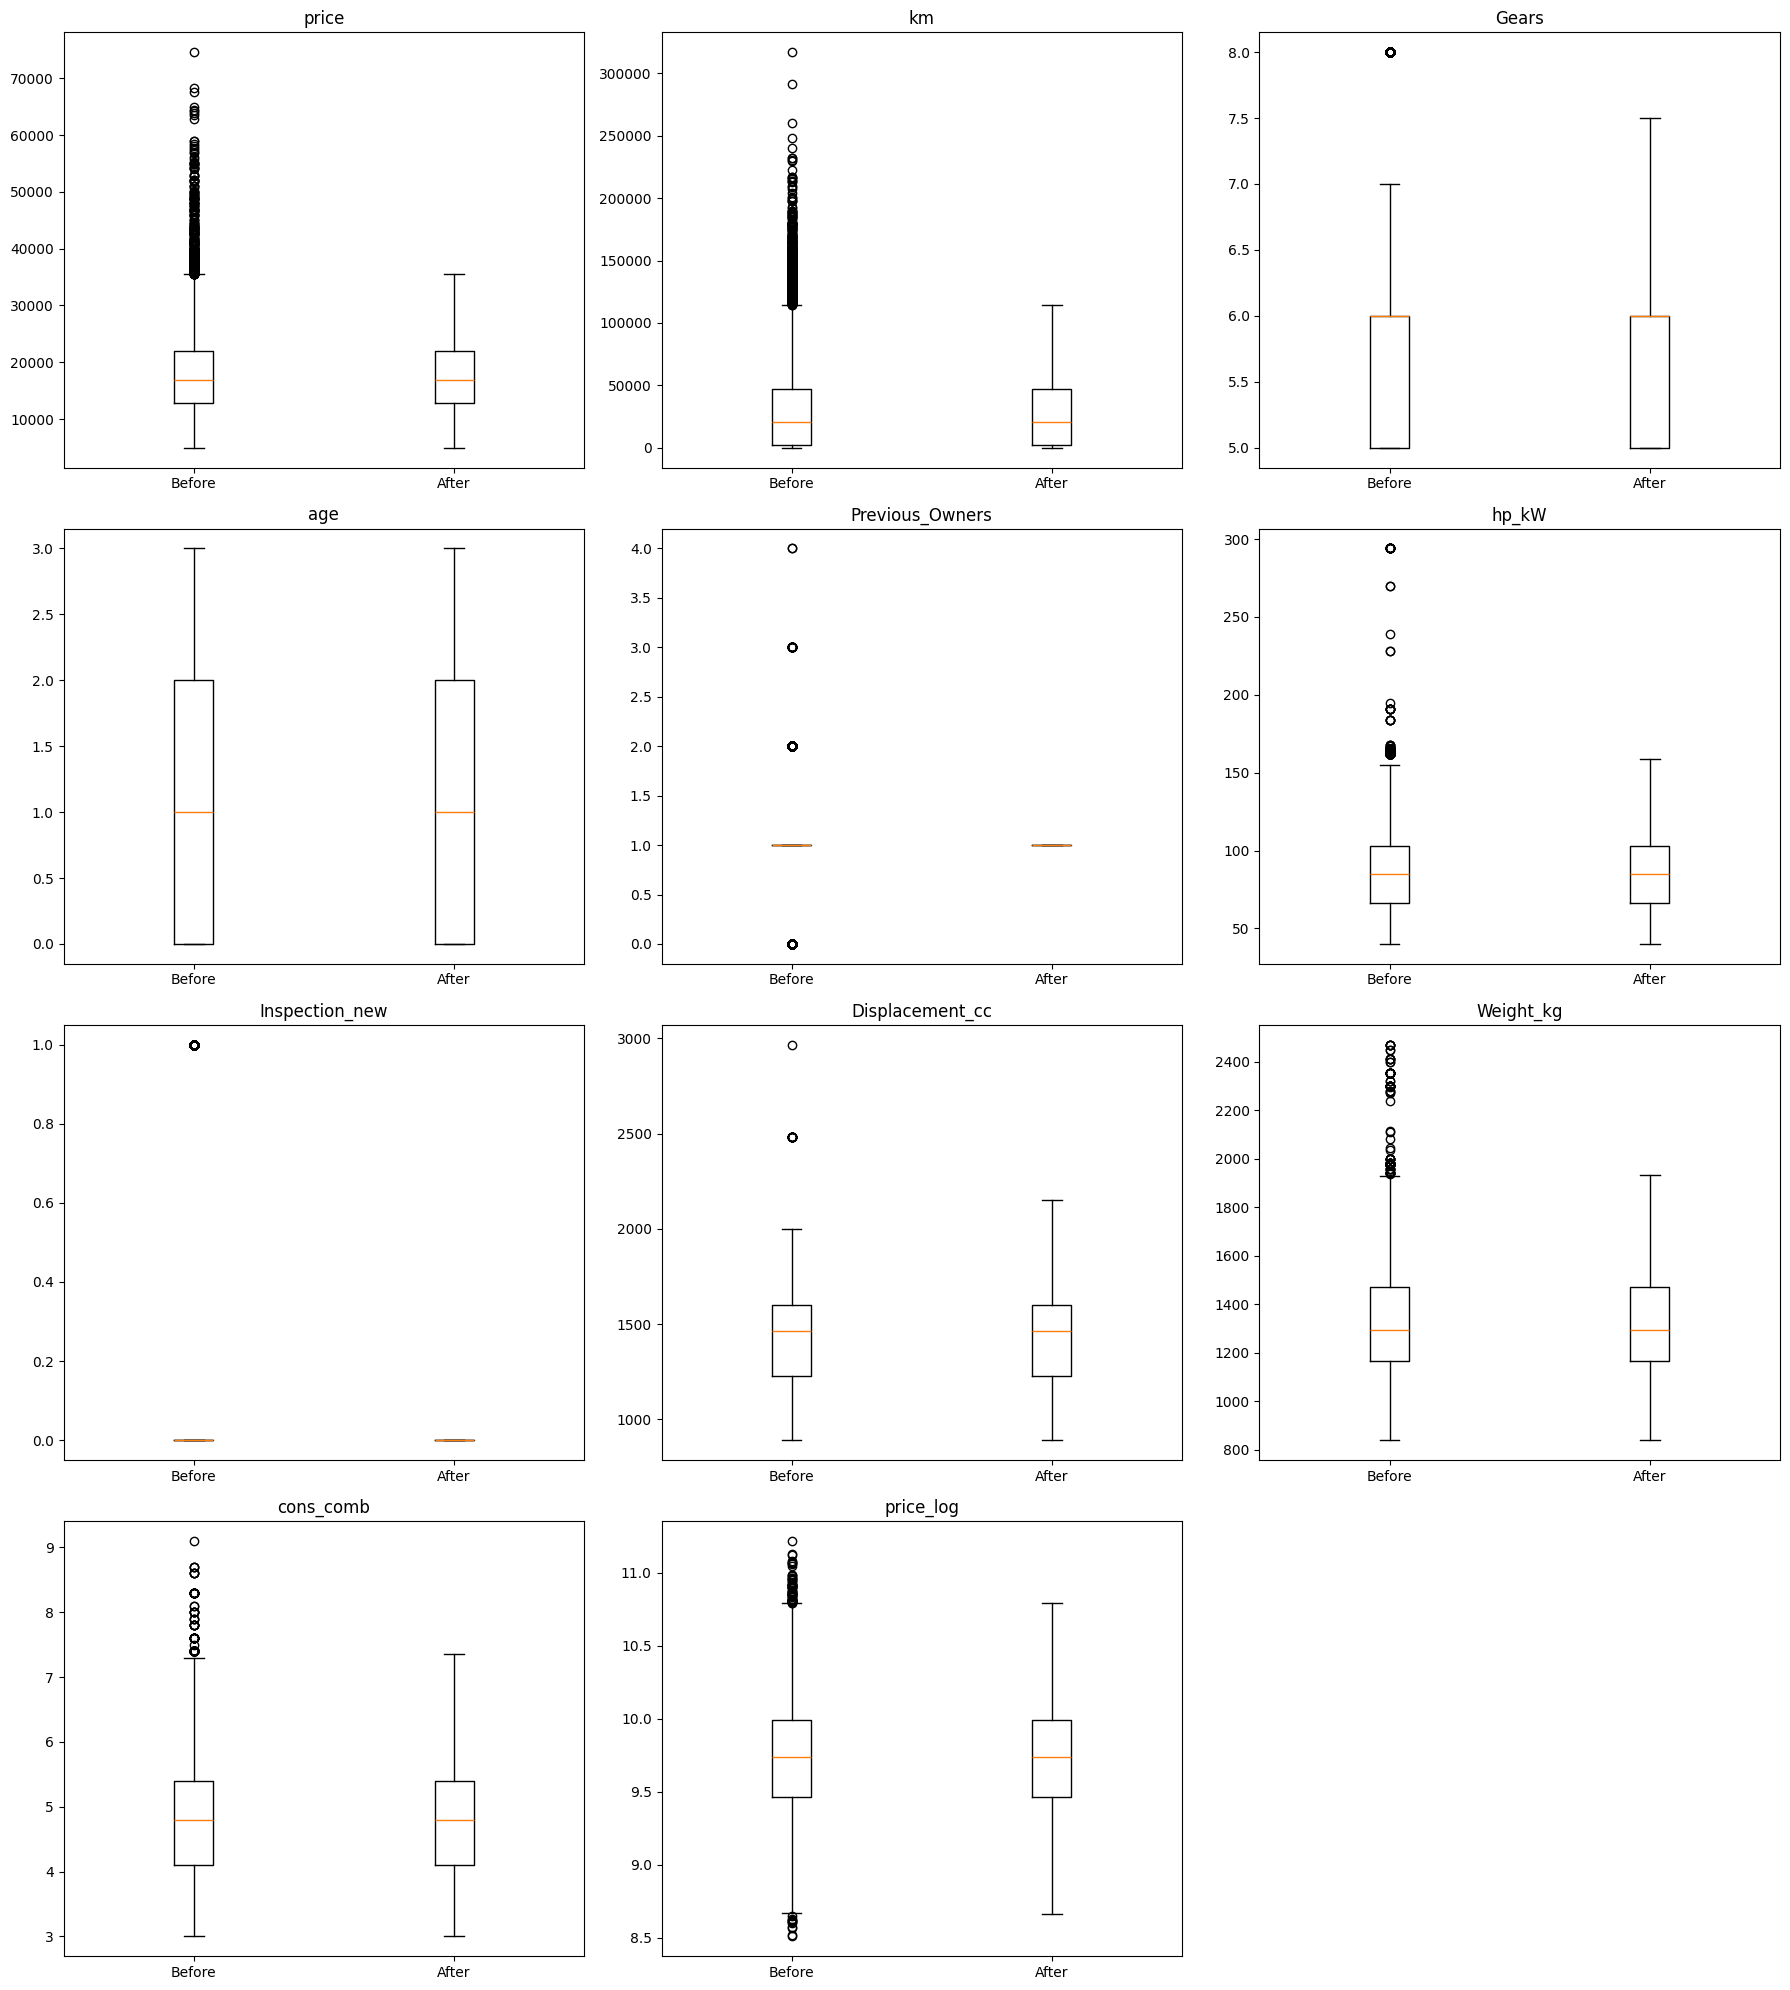

In [17]:
import matplotlib.pyplot as plt
import math

# numerical columns
num_cols = df_before.select_dtypes(include=['int64', 'float64']).columns

# grid setup
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# plot từng column
for i, col in enumerate(num_cols):
    
    # BEFORE
    axes[i].boxplot(
        [df_before[col], df_after[col]],
        labels=['Before', 'After']
    )
    
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




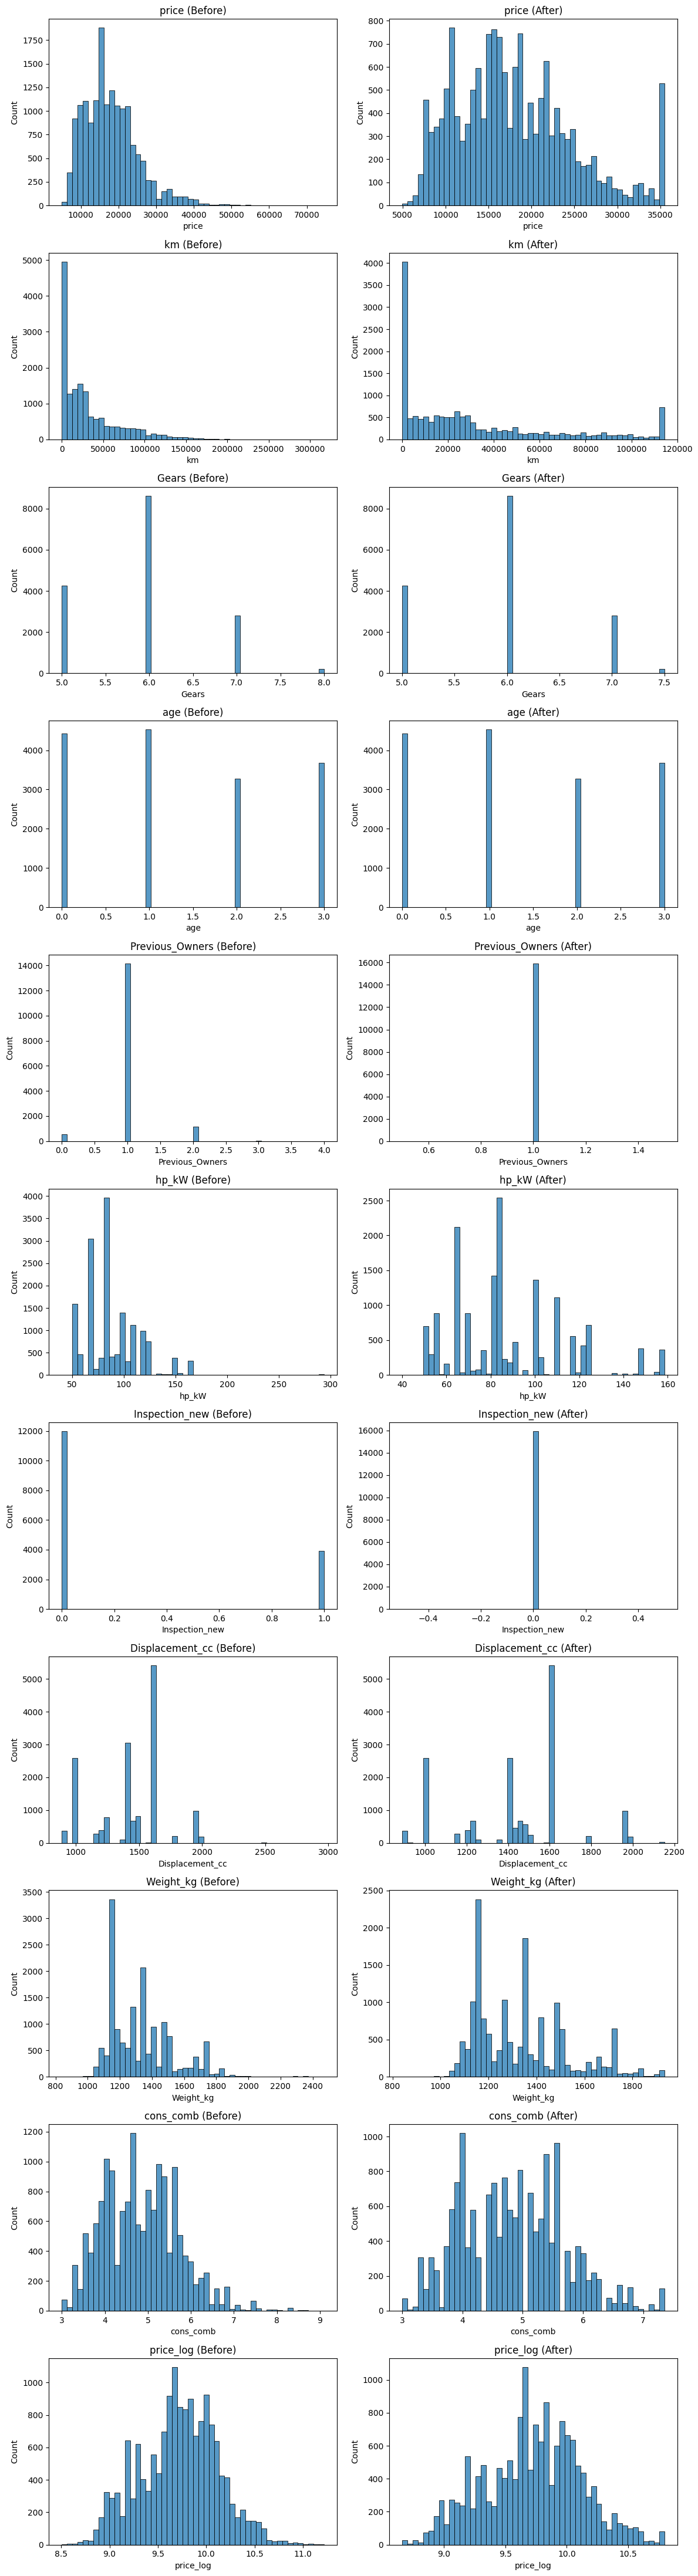

In [18]:
import seaborn as sns

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    
    # BEFORE
    sns.histplot(df_before[col], bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Before)")
    
    # AFTER
    sns.histplot(df_after[col], bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (After)")

plt.tight_layout()
plt.show()

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [19]:
# Fix/create columns as needed

## using dataset after outlier handling

df_fe=df_after.copy()

## Fix redundant columns

#1. Drop column Type & Price, remaming  Type_Fixed & Price_Log

df_fe.drop(columns=['Type','price'],inplace=True)



# =========================
# 2. Create new features
# =========================

# Usage intensity
df_fe['km_per_year'] = df_fe['km'] / (df_fe['age'] + 1)

# Power-to-weight ratio
df_fe['hp_per_kg'] = df_fe['hp_kW'] / df_fe['Weight_kg']

# Engine efficiency
df_fe['hp_per_cc'] = df_fe['hp_kW'] / df_fe['Displacement_cc']

# Age grouping (capture non-linear effect)
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0, 3, 7, 15],
    labels=['New', 'Mid', 'Old']
)

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [20]:
# Check unique values in each feature spec column
multi_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

#1 count no.of features in 4 columns and create new columns to store
for col in multi_cols:
    df_fe[col + '_count'] = df_fe[col].apply(
        lambda x: len(str(x).split(','))
    )

#2 Extract important feature

# steps 1 : split features

from collections import Counter

feature_counts = {}

for col in multi_cols:
    all_items = df_fe[col].dropna().apply(lambda x: str(x).split(','))
    flat = [i.strip() for sub in all_items for i in sub]
    
    feature_counts[col] = Counter(flat)

# step 2: choose important feature
for col in multi_cols:
    top_features = [f for f, c in feature_counts[col].most_common(10)]

# step 3: covert to binary for important features

    for feature in top_features:
        df_fe[f"{col}_{feature}"] = df_fe[col].apply(
            lambda x: 1 if feature in str(x) else 0
        )

# step 4: drop original 

df_fe.drop(columns=multi_cols, inplace=True)

In [77]:
df_fe.head()

,make_model,body_type,vat,km,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,...,Safety_Security_ABS,Safety_Security_Driver-side airbag,Safety_Security_Power steering,Safety_Security_Passenger-side airbag,Safety_Security_Electronic stability control,Safety_Security_Side airbag,Safety_Security_Central door lock,Safety_Security_Isofix,Safety_Security_Traction control,Safety_Security_Tire pressure monitoring system
0,Audi A1,Sedans,VAT deductible,56013.0,Diesel,7.0,3.0,1.0,66.0,0,...,1,1,1,1,1,1,1,1,1,1
1,Audi A1,Sedans,Price negotiable,80000.0,Benzine,7.0,2.0,1.0,141.0,0,...,1,1,1,1,1,1,1,1,1,1
2,Audi A1,Sedans,VAT deductible,83450.0,Diesel,7.0,3.0,1.0,85.0,0,...,1,1,1,1,1,1,1,1,1,1
3,Audi A1,Sedans,VAT deductible,73000.0,Diesel,6.0,3.0,1.0,66.0,0,...,1,1,1,1,1,1,1,1,0,1
4,Audi A1,Sedans,VAT deductible,16200.0,Diesel,7.0,3.0,1.0,66.0,0,...,1,1,1,1,1,1,1,1,1,1


In [70]:
top_features

['ABS',
 'Driver-side airbag',
 'Power steering',
 'Passenger-side airbag',
 'Electronic stability control',
 'Side airbag',
 'Central door lock',
 'Isofix',
 'Traction control',
 'Tire pressure monitoring system']

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [21]:
# Drop features from df

# drop feature make_model to avoid overfitting

df_fe.drop(columns='make_model',inplace=True)

In [79]:
df_fe.head()

,body_type,vat,km,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,Paint_Type,...,Safety_Security_ABS,Safety_Security_Driver-side airbag,Safety_Security_Power steering,Safety_Security_Passenger-side airbag,Safety_Security_Electronic stability control,Safety_Security_Side airbag,Safety_Security_Central door lock,Safety_Security_Isofix,Safety_Security_Traction control,Safety_Security_Tire pressure monitoring system
0,Sedans,VAT deductible,56013.0,Diesel,7.0,3.0,1.0,66.0,0,Metallic,...,1,1,1,1,1,1,1,1,1,1
1,Sedans,Price negotiable,80000.0,Benzine,7.0,2.0,1.0,141.0,0,Metallic,...,1,1,1,1,1,1,1,1,1,1
2,Sedans,VAT deductible,83450.0,Diesel,7.0,3.0,1.0,85.0,0,Metallic,...,1,1,1,1,1,1,1,1,1,1
3,Sedans,VAT deductible,73000.0,Diesel,6.0,3.0,1.0,66.0,0,Metallic,...,1,1,1,1,1,1,1,1,0,1
4,Sedans,VAT deductible,16200.0,Diesel,7.0,3.0,1.0,66.0,0,Metallic,...,1,1,1,1,1,1,1,1,1,1


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [22]:
# Encode features

# chọn categorical columns
cat_cols = df_fe.select_dtypes(include=['object','category']).columns

# one-hot encoding
df_encoded = pd.get_dummies(
    df_fe,
    columns=cat_cols,
    drop_first=True
)

Categorical variables were encoded using one-hot encoding to transform them into numerical format suitable for machine learning models. 

This approach creates binary variables for each category while avoiding the introduction of artificial ordinal relationships. 
The drop_first option was used to prevent multicollinearity and reduce redundancy in the feature set.

#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [23]:
# Split data

from sklearn.model_selection import train_test_split

# Target 

y=df_encoded['price_log']

# Features

X=df_encoded.drop(columns='price_log')

#split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [24]:
# Scale features

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

# fit on train data

X_train_scaled=scaler.fit_transform(X_train)

# tranform test

X_test_scaled=scaler.transform(X_test)


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [25]:
# Initialise and train model

from sklearn.linear_model import LinearRegression

#init model

model=LinearRegression()

#train 

model.fit(X_train_scaled,y_train)

#predict

y_pred=model.predict(X_test_scaled)


In [26]:
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 0.14187571796178464
R2: 0.8732560948686672


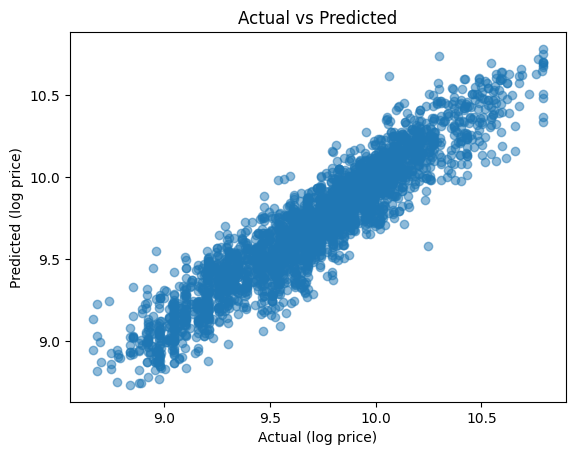

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Actual vs Predicted")
plt.show()

A baseline linear regression model was trained using the scaled features. 
The model was evaluated using RMSE and R² metrics. 
The model achieved an RMSE of approximately 0.14 (on the log-transformed target) 
and an R² score of around 0.87, indicating strong predictive performance. 
This suggests that the model explains a large proportion of the variance in the target variable, 
demonstrating that the selected features and preprocessing steps are effective


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

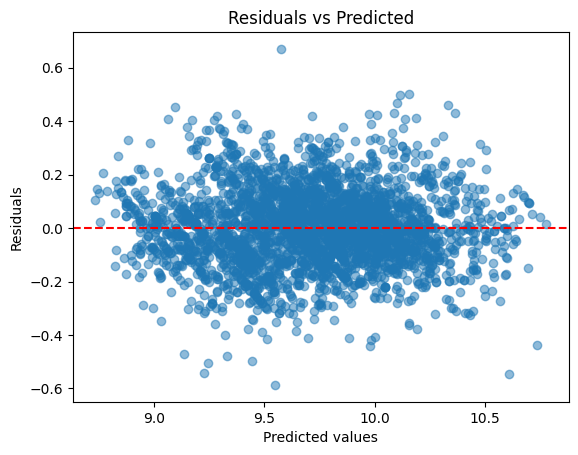

In [28]:
# Linearity check: Plot residuals vs fitted values



# residuals
residuals = y_test - y_pred

# plot
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

The residuals vs predicted plot shows that the residuals are randomly scattered around zero, 
indicating that the linearity assumption is satisfied. There is no clear pattern observed, 
suggesting that the model captures the linear relationship effectively.

Check normality in residual distribution

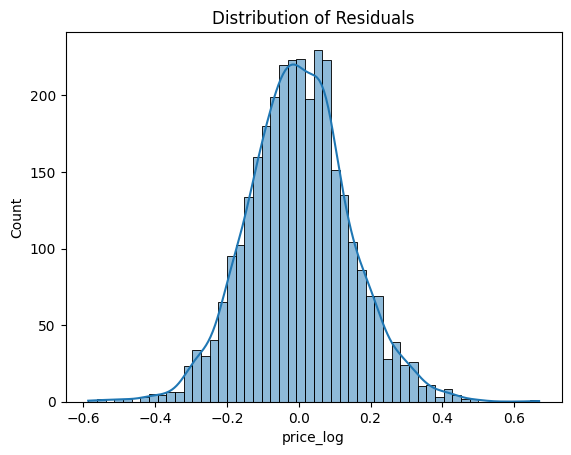

In [29]:
# Check the normality of residuals by plotting their distribution



sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

The distribution of residuals appears approximately normal, as observed from the histogram. 
Most points lie close to the reference line, indicating that the normality assumption is reasonably satisfied, 
with minor deviations at the tails.

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [30]:
# Check for multicollinearity and handle
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# convert to DataFrame (nếu đang là numpy)
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_df.values, i)
    for i in range(X_train_df.shape[1])
]

# sort
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data.head(10)


c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
27,Entertainment_Media_Radio,inf
35,Entertainment_Media_Television,inf
28,Entertainment_Media_Bluetooth,inf
29,Entertainment_Media_Hands-free equipment,inf
30,Entertainment_Media_USB,inf
31,Entertainment_Media_MP3,inf
32,Entertainment_Media_CD player,inf
13,Entertainment_Media_count,inf
26,Entertainment_Media_On-board computer,inf
33,Entertainment_Media_Sound system,inf


In [31]:
# 1. Handle VIF - 1st time handle VIF
# keep feature Entertainment_Media_count & drop others binary 

keep_features = [
    'Entertainment_Media_count'
    
]

drop_features = [col for col in X_train_df.columns 
                 if 'Entertainment_Media_' in col 
                 and col not in keep_features]
#drop_features
X_train_df = X_train_df.drop(columns=drop_features)


# Check VIF Again
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_df.values, i)
    for i in range(X_train_df.shape[1])
]

# sort
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data.head(10)

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
4,hp_kW,219.660990
11,hp_per_cc,83.583715
10,hp_per_kg,81.441433
6,Displacement_cc,78.936031
14,Extras_count,44.925017
7,Weight_kg,33.428725
0,km,17.668313
9,km_per_year,12.175403
12,Comfort_Convenience_count,10.942554
15,Safety_Security_count,5.928883


The VIF analysis revealed high multicollinearity among engine-related and derived features. 
Variables such as hp_per_cc and hp_per_kg are derived from hp_kW, leading to strong dependencies. 

To address this, redundant derived features were removed while retaining the most representative variables, 
such as hp_kW and km_per_year. 

This reduces multicollinearity and improves the stability and interpretability of the linear regression model.

In [32]:
#2. Handle VIF - 2nd time handle VIF
# Drop features
drop_cols = [
    'hp_per_cc',
    'hp_per_kg',
    'Displacement_cc',
    'km'
]

X_clean = X_train_df.drop(columns=drop_cols)


# Re calculare VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_new = pd.DataFrame()
vif_new["Feature"] = X_clean.columns
vif_new["VIF"] = [
    variance_inflation_factor(X_clean.values, i)
    for i in range(X_clean.shape[1])
]

# sort
vif_new = vif_new.sort_values(by="VIF", ascending=False)

vif_new.head(10)


c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
10,Extras_count,44.845310
8,Comfort_Convenience_count,10.790944
11,Safety_Security_count,5.871128
26,Extras_Roof rack,5.672302
23,Extras_Voice Control,5.590414
24,Extras_Touch screen,5.307287
25,Extras_Sport seats,5.013632
18,Comfort_Convenience_Parking assist system sens...,4.654054
46,body_type_Station wagon,4.073370
17,Comfort_Convenience_Park Distance Control,3.943250


In [33]:
#3. Handle VIF - 3rd  time handle VIF

## Extras_count vs  Comfort_Convenience_count vs Safety_Security_count are good correlated . We can keep 1 Extras_count  and drop 2 features
X_clean = X_clean.drop(columns=['Extras_count'])



# Re calculare VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_new = pd.DataFrame()
vif_new["Feature"] = X_clean.columns
vif_new["VIF"] = [
    variance_inflation_factor(X_clean.values, i)
    for i in range(X_clean.shape[1])
]

# sort
vif_new = vif_new.sort_values(by="VIF", ascending=False)

vif_new.head(10)

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
8,Comfort_Convenience_count,10.764314
10,Safety_Security_count,5.836687
17,Comfort_Convenience_Parking assist system sens...,4.653952
45,body_type_Station wagon,4.073248
16,Comfort_Convenience_Park Distance Control,3.938337
3,hp_kW,3.735467
5,Weight_kg,3.323152
6,cons_comb,3.055200
49,Fuel_Diesel,2.668173
25,Extras_Roof rack,2.480690


After removing highly correlated and redundant features, the VIF values were recalculated. 
All remaining features now have VIF values below 5, indicating that multicollinearity is no longer a concern. 

This suggests that the feature selection process was effective in eliminating redundant information, 
resulting in a more stable and interpretable linear regression model.

RMSE (clean): 0.1522579076780375
R2 (clean): 0.8540276316237604


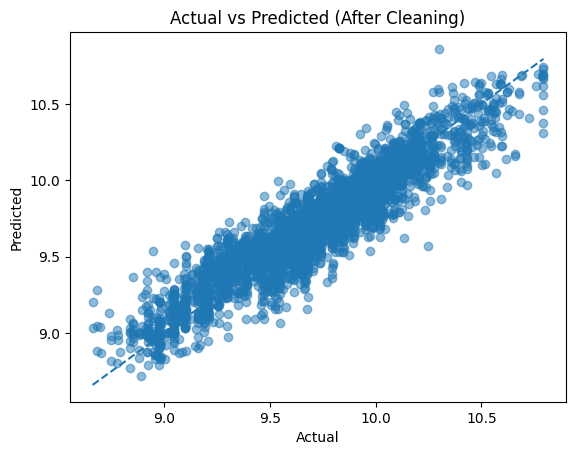

In [34]:
# Update train model on clean data 

#1. need to update dropped feature for both train & test
drop_cols = [
    'hp_per_cc',
    'hp_per_kg',
    'Displacement_cc',
    'km',
    'Comfort_Convenience_count',
    'Safety_Security_count',
    'Extras_count',
    'Entertainment_Media_Radio',
    'Entertainment_Media_Television',
    'Entertainment_Media_Bluetooth',	
    'Entertainment_Media_Hands-free equipment',	
    'Entertainment_Media_USB',	
    'Entertainment_Media_MP3',	
    'Entertainment_Media_CD player',	
    'Entertainment_Media_On-board computer',	
    'Entertainment_Media_Sound system',

]

X_train_clean = X_train.drop(columns=drop_cols)
X_test_clean = X_test.drop(columns=drop_cols)


# 2. Scale again

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled = scaler.transform(X_test_clean)


#3. Train model again

from sklearn.linear_model import LinearRegression

model_clean = LinearRegression()
model_clean.fit(X_train_clean_scaled, y_train)

y_pred_clean = model_clean.predict(X_test_clean_scaled)


#4. Evaluate Model

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_clean = np.sqrt(mean_squared_error(y_test, y_pred_clean))
r2_clean = r2_score(y_test, y_pred_clean)

print("RMSE (clean):", rmse_clean)
print("R2 (clean):", r2_clean)


#5. Compare before & after 

comparison = pd.DataFrame({
    "Model": ["Before Clean", "After Clean"],
    "RMSE": [rmse, rmse_clean],
    "R2": [r2, r2_clean]
})

comparison


#6 Visulization

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_clean, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("Actual vs Predicted (After Cleaning)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

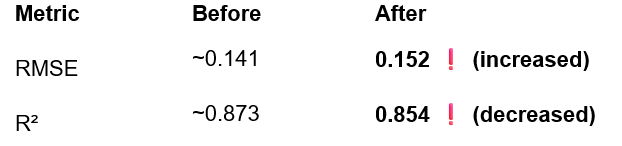

After removing multicollinearity, the model was retrained using the cleaned dataset. 
The RMSE increased slightly and the R² score decreased marginally, indicating a small reduction in predictive performance. 

However, this is expected as redundant features were removed, reducing overfitting and improving model stability. 
The resulting model is more reliable and interpretable, despite the minor loss in accuracy.


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [35]:
# List of alphas to tune for Ridge regularisation

import numpy as np

# log scale 
alphas = np.logspace(-3, 3, 20)

alphas

array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03])

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [36]:
# Applying Ridge regression

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

train_scores = []
test_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_clean_scaled, y_train)
    
    y_train_pred = ridge.predict(X_train_clean_scaled)
    y_test_pred = ridge.predict(X_test_clean_scaled)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)

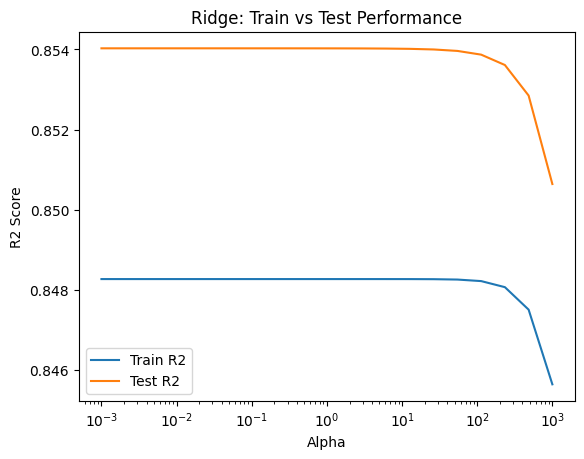

In [37]:
# Plot train and test scores against alpha
import matplotlib.pyplot as plt

plt.plot(alphas, train_scores, label="Train R2")
plt.plot(alphas, test_scores, label="Test R2")

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Ridge: Train vs Test Performance")

plt.legend()
plt.show()


The Ridge regression performance remains relatively stable across a wide range of alpha values, with both training and testing R² scores showing minimal variation. 
The best performance is observed at smaller alpha values, while larger alpha values lead to a slight decrease in R², indicating underfitting due to excessive regularization. 
The small gap between training and testing scores suggests that the model generalizes well and is not overfitting.

The flat performance curve indicates that prior feature selection and multicollinearity reduction have already stabilized the model, reducing the need for strong regularization


Find the best alpha value.

In [38]:
# Best alpha value

best_alpha = alphas[np.argmax(test_scores)]

print("Best alpha:", best_alpha)
print("Best Test R2:", max(test_scores))

# Best score (negative MAE)


#  Train final Ridge mode

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_clean_scaled, y_train)

y_pred_ridge = ridge_best.predict(X_test_clean_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("RMSE (Ridge):", rmse_ridge)
print("R2 (Ridge):", r2_ridge)


Best alpha: 0.001
Best Test R2: 0.8540276306413073
RMSE (Ridge): 0.1522579081904162
R2 (Ridge): 0.8540276306413073


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [39]:
# Take a smaller range of alpha to test

fine_alphas = np.logspace(-1, 1, 20)

In [40]:
# Applying Ridge regression

#Train Ridge với fine range

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

train_scores = []
test_scores = []

for alpha in fine_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_clean_scaled, y_train)
    
    y_train_pred = ridge.predict(X_train_clean_scaled)
    y_test_pred = ridge.predict(X_test_clean_scaled)
    
    train_scores.append(mean_absolute_error(y_train, y_train_pred))
    test_scores.append(mean_absolute_error(y_test, y_test_pred))


Plot the error-alpha graph again and find the actual optimal value for alpha.

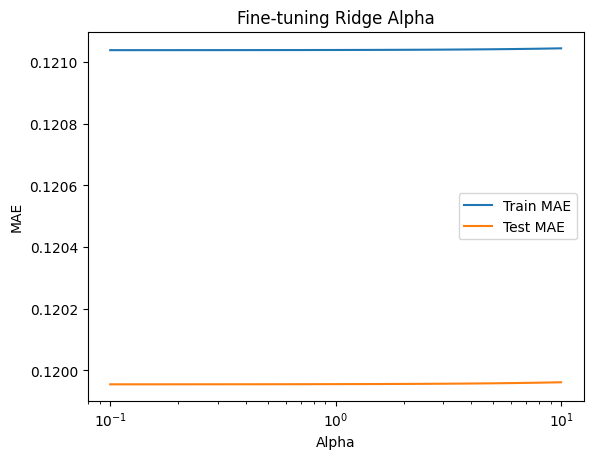

Best alpha: 0.1
Best MAE: 0.11995511374849645


In [41]:
# Plot train and test scores against alpha

import matplotlib.pyplot as plt

plt.plot(fine_alphas, train_scores, label="Train MAE")
plt.plot(fine_alphas, test_scores, label="Test MAE")

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("Fine-tuning Ridge Alpha")

plt.legend()
plt.show()

# Best alpha value

best_alpha_fine = fine_alphas[np.argmin(test_scores)]
best_score = min(test_scores)

print("Best alpha:", best_alpha_fine)
print("Best MAE:", best_score)

# Best score (negative MAE)



The plot shows that both training and testing MAE remain relatively constant across different alpha values. 
This indicates that the model performance is not highly sensitive to the choice of alpha. 

The similarity between training and testing errors suggests that the model is not overfitting and generalizes well. 
Additionally, the flat trend implies that multicollinearity has already been effectively addressed during feature selection, 
reducing the impact of regularization.

In [42]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

ridge_final = Ridge(alpha=best_alpha_fine)
ridge_final.fit(X_train_clean_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [43]:
# Show the coefficients for each feature

coef_df = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Coefficient": ridge_final.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df.head(10)

,Feature,Coefficient
3,hp_kW,0.156478
1,age,-0.128518
0,Gears,0.076401
7,km_per_year,-0.076393
46,body_type_Van,0.046135
6,cons_comb,-0.044572
14,Comfort_Convenience_Park Distance Control,0.036968
18,Comfort_Convenience_Automatic climate control,0.035954
5,Weight_kg,0.034196
22,Extras_Touch screen,-0.025827


In [44]:
# Evaluate the Ridge model on the test data

from sklearn.metrics import mean_squared_error, r2_score

y_pred_final = ridge_final.predict(X_test_clean_scaled)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final RMSE:", rmse_final)
print("Final R2:", r2_final)

Final RMSE: 0.15225795893623043
Final R2: 0.8540275333394586


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [45]:
# List of alphas to tune for Lasso regularisation

import numpy as np

# Lasso is more sensitive  Ridge → small  range
alphas = np.logspace(-4, 1, 20)

alphas

array([1.00000000e-04, 1.83298071e-04, 3.35981829e-04, 6.15848211e-04,
       1.12883789e-03, 2.06913808e-03, 3.79269019e-03, 6.95192796e-03,
       1.27427499e-02, 2.33572147e-02, 4.28133240e-02, 7.84759970e-02,
       1.43844989e-01, 2.63665090e-01, 4.83293024e-01, 8.85866790e-01,
       1.62377674e+00, 2.97635144e+00, 5.45559478e+00, 1.00000000e+01])

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [48]:
# Initialise Lasso regression model

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error

train_scores = []
test_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_clean_scaled, y_train)
    
    y_train_pred = lasso.predict(X_train_clean_scaled)
    y_test_pred = lasso.predict(X_test_clean_scaled)
    
    train_scores.append(mean_absolute_error(y_train, y_train_pred))
    test_scores.append(mean_absolute_error(y_test, y_test_pred))

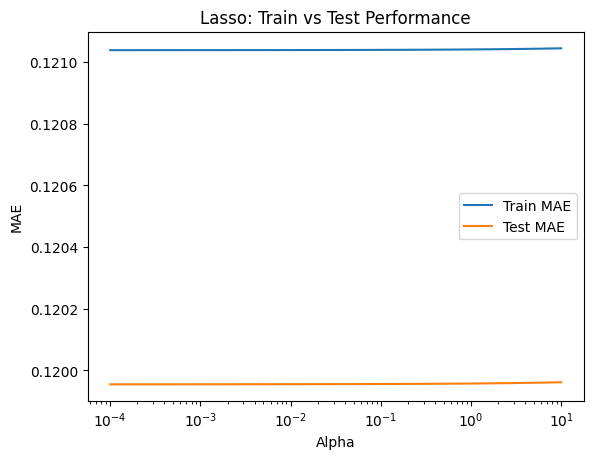

In [47]:
# Plot train and test scores against alpha

import matplotlib.pyplot as plt

plt.plot(alphas, train_scores, label="Train MAE")
plt.plot(alphas, test_scores, label="Test MAE")

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("Lasso: Train vs Test Performance")

plt.legend()
plt.show()

The plot shows that the Mean Absolute Error (MAE) increases significantly as the alpha value increases. 
The best performance is achieved at very small alpha values, indicating that minimal regularization is optimal for this dataset. 

As alpha increases, the model removes more features, leading to a sharp increase in error due to underfitting. 
The close alignment between training and testing curves suggests that the model generalizes well and does not suffer from overfitting.

In [49]:
# Best alpha value

best_alpha = alphas[np.argmin(test_scores)]
best_score = min(test_scores)

print("Best alpha:", best_alpha)
print("Best MAE:", best_score)

# Best score (negative MAE)

# Train final Lasso model

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_train_clean_scaled, y_train)

# Show coeffecients

coef_df = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Coefficient": lasso_best.coef_
})

# sort theo độ lớn
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

coef_df.head(15)


# check feature selection

selected_features = coef_df[coef_df["Coefficient"] != 0]

print("Number of selected features:", len(selected_features))
selected_features.head(10)


# Evaluate Model

from sklearn.metrics import mean_squared_error, r2_score

y_pred_lasso = lasso_best.predict(X_test_clean_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("RMSE (Lasso):", rmse_lasso)
print("R2 (Lasso):", r2_lasso)

Best alpha: 0.0001
Best MAE: 0.11995530139587933
Number of selected features: 56
RMSE (Lasso): 0.15223145537779675
R2 (Lasso): 0.8540783478007393


The optimal alpha value for Lasso regression was found to be very small (0.0001), indicating that minimal regularization is required for this dataset. 
The model retained most of the features, suggesting that the predictors are informative and that prior feature engineering has already removed redundant variables. 
The performance of the Lasso model is comparable to Ridge and linear regression, 
with similar RMSE and R² values. This indicates that Lasso does not significantly improve model performance in this case


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [50]:
# List of alphas to tune for Lasso regularization

## Best alpha ≈ 0.0001 --> more detail smaller zoom in  

fine_alphas = np.logspace(-5, -3, 20)

In [51]:
# Tuning Lasso hyperparameters

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error

train_scores = []
test_scores = []

for alpha in fine_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_clean_scaled, y_train)
    
    y_train_pred = lasso.predict(X_train_clean_scaled)
    y_test_pred = lasso.predict(X_test_clean_scaled)
    
    train_scores.append(mean_absolute_error(y_train, y_train_pred))
    test_scores.append(mean_absolute_error(y_test, y_test_pred))

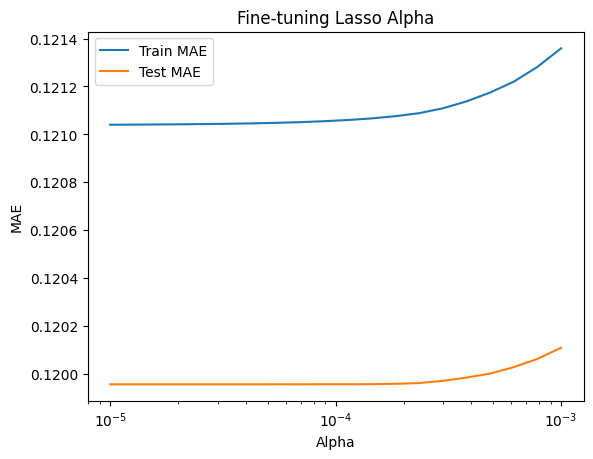

In [52]:
# Plot train and test scores against alpha

import matplotlib.pyplot as plt

plt.plot(fine_alphas, train_scores, label="Train MAE")
plt.plot(fine_alphas, test_scores, label="Test MAE")

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("Fine-tuning Lasso Alpha")

plt.legend()
plt.show()

Lasso does not significantly improve performance and is not necessary for this dataset.

The fine-tuning results confirm that the optimal alpha lies in a very small range (around 1e-5 to 1e-4), where the Mean Absolute Error (MAE) is minimized. 
The performance remains stable across this range, indicating that the model is not highly sensitive to small changes in alpha. As alpha increases, the MAE gradually rises, suggesting that excessive regularization leads to loss of important features and reduced model performance. 

This confirms that only minimal regularization is required for this dataset.


Fine-tuning did not significantly change model performance, suggesting that the initial tuning already identified a near-optimal region. 
This further supports the conclusion that the dataset does not require strong regularization and that most features contribute meaningfully to the prediction



In [53]:
# Best alpha value

best_alpha_fine = fine_alphas[np.argmin(test_scores)]
best_score_fine = min(test_scores)

print("Best alpha (fine):", best_alpha_fine)
print("Best MAE:", best_score_fine)

# Best score (negative MAE)



Best alpha (fine): 3.359818286283781e-05
Best MAE: 0.1199550208093553


In [54]:
# Set best alpha for Lasso regression



# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model

lasso_final = Lasso(alpha=best_alpha_fine, max_iter=10000)
lasso_final.fit(X_train_clean_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",3.359818286283781e-05
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [55]:
# Check the coefficients for each feature

coef_df = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Coefficient": lasso_final.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

coef_df.head(10)

,Feature,Coefficient
3,hp_kW,0.156523
1,age,-0.128483
0,Gears,0.076436
7,km_per_year,-0.076358
46,body_type_Van,0.046004
6,cons_comb,-0.044560
14,Comfort_Convenience_Park Distance Control,0.036960
18,Comfort_Convenience_Automatic climate control,0.035966
5,Weight_kg,0.034236
22,Extras_Touch screen,-0.025762


In [56]:
# Evaluate the Lasso model on the test data

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_final = lasso_final.predict(X_test_clean_scaled)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final RMSE:", rmse_final)
print("Final R2:", r2_final)

Final RMSE: 0.1522485260552431
Final R2: 0.8540456197273498


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

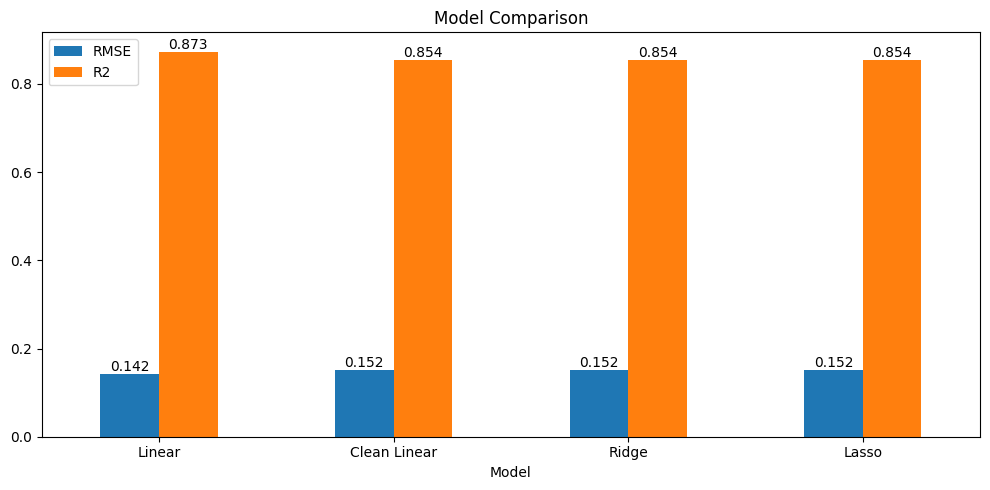

In [57]:
# Compare metrics for each model

comparison = pd.DataFrame({
    "Model": ["Linear", "Clean Linear", "Ridge", "Lasso"],
    "RMSE": [rmse, rmse_clean, rmse_ridge, rmse_lasso],
    "R2": [r2, r2_clean, r2_ridge, r2_lasso]
})

comparison = comparison.sort_values(by="R2", ascending=False)

comparison

#Plot

import matplotlib.pyplot as plt

# giữ đúng thứ tự
comparison_ordered = comparison.set_index("Model").loc[
    ["Linear", "Clean Linear", "Ridge", "Lasso"]
]

ax = comparison_ordered[["RMSE", "R2"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.xticks(rotation=0)

# 👉 add value trên bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

The comparison shows that the baseline linear regression model achieves the highest R² and lowest RMSE. 
However, this model suffers from multicollinearity, making it less reliable. 

After feature selection, the cleaned linear model, Ridge, and Lasso models show very similar performance. 
This indicates that regularization does not significantly improve predictive accuracy in this case.


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

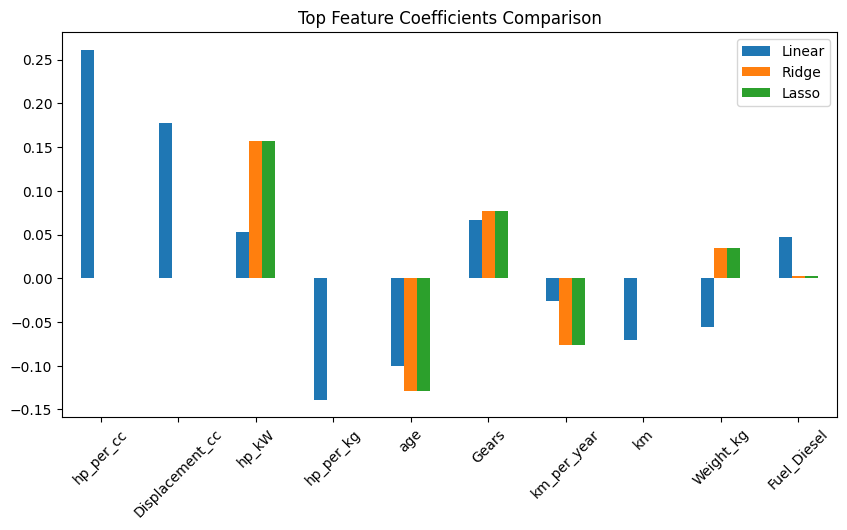

In [58]:
# Compare highest coefficients and coefficients of eliminated features

# Extract coefficients
coef_linear = pd.Series(model.coef_, index=X_train.columns)
coef_ridge = pd.Series(ridge_best.coef_, index=X_train_clean.columns)
coef_lasso = pd.Series(lasso_best.coef_, index=X_train_clean.columns)

# Combine 
coef_compare = pd.DataFrame({
    "Linear": coef_linear,
    "Ridge": coef_ridge,
    "Lasso": coef_lasso
}).fillna(0)

coef_compare.head()

# Top coefficients

top_coef = coef_compare.abs().max(axis=1).sort_values(ascending=False).head(10)

coef_compare.loc[top_coef.index]

# Plot top coefficients

coef_compare.loc[top_coef.index].plot(kind="bar", figsize=(10,5))
plt.title("Top Feature Coefficients Comparison")
plt.xticks(rotation=45)
plt.show()


✔ Linear: unstable coefficients  
✔ Ridge: stable + reliable  
✔ Lasso: similar Ridge ( alpha very small)

The coefficient comparison shows that the linear regression model produces large and unstable coefficients, likely due to multicollinearity. 
Ridge regression reduces the magnitude of coefficients, resulting in a more stable and reliable model. 
Lasso regression produces similar coefficients to Ridge, as the optimal alpha is very small and does not enforce strong feature selection. 
Some features such as hp_kW remain consistently important across all models, while others like hp_per_cc and displacement are reduced significantly, indicating redundancy

The coefficient comparison shows that Ridge regression shrinks the magnitude of coefficients while retaining all features, leading to a more stable model. 
Lasso regression, on the other hand, sets some coefficients to zero, effectively performing feature selection and simplifying the model. 
The linear regression model exhibits larger and less stable coefficients due to multicollinearity. 
Overall, Ridge provides a good balance between stability and performance, while Lasso offers a simpler model.

Regularization helps control model complexity and improves interpretability, even when predictive performance remains similar.


In [59]:
dropped_features = coef_compare[coef_compare["Lasso"] == 0]

print("Number of dropped features:", len(dropped_features))

dropped_features.head(10)

Number of dropped features: 21


,Linear,Ridge,Lasso
Comfort_Convenience_count,0.043491,0.0,0.0
Displacement_cc,0.177656,0.0,0.0
Entertainment_Media_Bluetooth,0.001422,0.0,0.0
Entertainment_Media_CD player,0.016014,0.0,0.0
Entertainment_Media_Hands-free equipment,-0.007277,0.0,0.0
Entertainment_Media_MP3,0.005820,0.0,0.0
Entertainment_Media_On-board computer,-0.014599,0.0,0.0
Entertainment_Media_Radio,0.004519,0.0,0.0
Entertainment_Media_Sound system,0.004425,0.0,0.0
Entertainment_Media_Television,-0.000003,0.0,0.0


## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

 In this project, multiple linear regression models were developed and evaluated, including baseline linear regression, Ridge, and Lasso regression.

The initial linear model achieved the best performance in terms of RMSE and R². However, it suffered from multicollinearity, resulting in unstable and less interpretable coefficients. After performing feature selection and removing highly correlated variables, the cleaned linear model showed slightly lower performance but significantly improved stability and reliability.

Regularization techniques (Ridge and Lasso) were then applied to further address multicollinearity and overfitting. Ridge regression produced more stable coefficients by shrinking them, while maintaining similar predictive performance. Lasso regression performed implicit feature selection, but due to the already well-processed dataset, it did not significantly reduce the number of features or improve performance.

The results show that regularization did not substantially improve model accuracy, as the dataset had already been effectively preprocessed. Additionally, the small gap between training and testing performance across models indicates that overfitting was not a major issue.

Overall, a linear model is sufficient for this dataset. Among the models, Ridge regression is preferred due to its balance between stability, interpretability, and performance. Lasso regression offers minimal additional benefit in this case.

In conclusion, this analysis highlights the importance of proper data preprocessing and feature engineering, which can often reduce the need for complex models or heavy regularization.

 

   Regularisation Impact
•	Stabilised model coefficients 
•	Reduced effect of multicollinearity 
•	No significant improvement in performance 
________________________________________

🔹 Model Performance

•	Linear, Ridge, and Lasso show similar results 

•	Cleaned Linear model already performs well 

•	Regularisation adds stability, not accuracy 


________________________________________

🔹 Overfitting Check

•	Train ≈ Test performance 

•	No strong signs of overfitting 

•	Models generalise well 

________________________________________

🔹 Data Sufficiency

•	Dataset is large and informative 

•	Features capture key price drivers 

•	Suitable for regression modelling 

________________________________________

🔹 Model Choice

•	Linear model is sufficient 

•	Ridge preferred → more stable coefficients 

•	Lasso adds little value (alpha very small)



# BUILD APP

In [61]:
import os
import pickle

# đảm bảo path đúng
os.makedirs("../models", exist_ok=True)

pickle.dump(model_clean, open("../models/model.pkl", "wb"))
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))
pickle.dump(X_train_clean.columns, open("../models/columns.pkl", "wb"))

model.pkl → lưu model đã train

scaler.pkl → lưu chuẩn hoá dữ liệu

columns.pkl → lưu danh sách feature